In [1]:
!pip install --upgrade sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 62.8 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
!pip install kaggle

In [4]:
from google.colab import drive, files
drive.mount('/content/drive')
print(" upload kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d briscdataset/brisc2025
!unzip -q brisc2025.zip

Mounted at /content/drive
 upload kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 248M/248M [00:00<00:00, 582MB/s] 
100% 248M/248M [00:00<00:00, 634MB/s]


In [5]:
img_dir = "/content/brisc2025/segmentation_task/train/images"
mask_dir = "/content/brisc2025/segmentation_task/train/masks"

# Verify paths exist
if not os.path.exists(img_dir):
    print(f"Image directory not found: {img_dir}")
    print("Available directories:", os.listdir("/content/brisc2025/segmentation_task/train/"))

if not os.path.exists(mask_dir):
    print(f"Mask directory not found: {mask_dir}")

# Get file lists
img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]

print(f"Found {len(img_files)} images and {len(mask_files)} masks")

# Match images with their corresponding masks
img_base_names = [os.path.splitext(f)[0] for f in img_files]
mask_base_names = [os.path.splitext(f)[0] for f in mask_files]

common_base_names = set(img_base_names).intersection(mask_base_names)
print(f"Found {len(common_base_names)} matching image-mask pairs")
data = []

for key in common_base_names:
    img_path = os.path.join(img_dir, f"{key}.jpg")
    mask_path = os.path.join(mask_dir, f"{key}.png")
    data.append((img_path, mask_path))

df = pd.DataFrame(data, columns=['image_path', 'mask_path'])
df['label'] = np.random.randint(0, 2, size=len(df))

print(f"Dataset shape: {df.shape}")

Found 3933 images and 3933 masks
Found 3933 matching image-mask pairs
Dataset shape: (3933, 3)


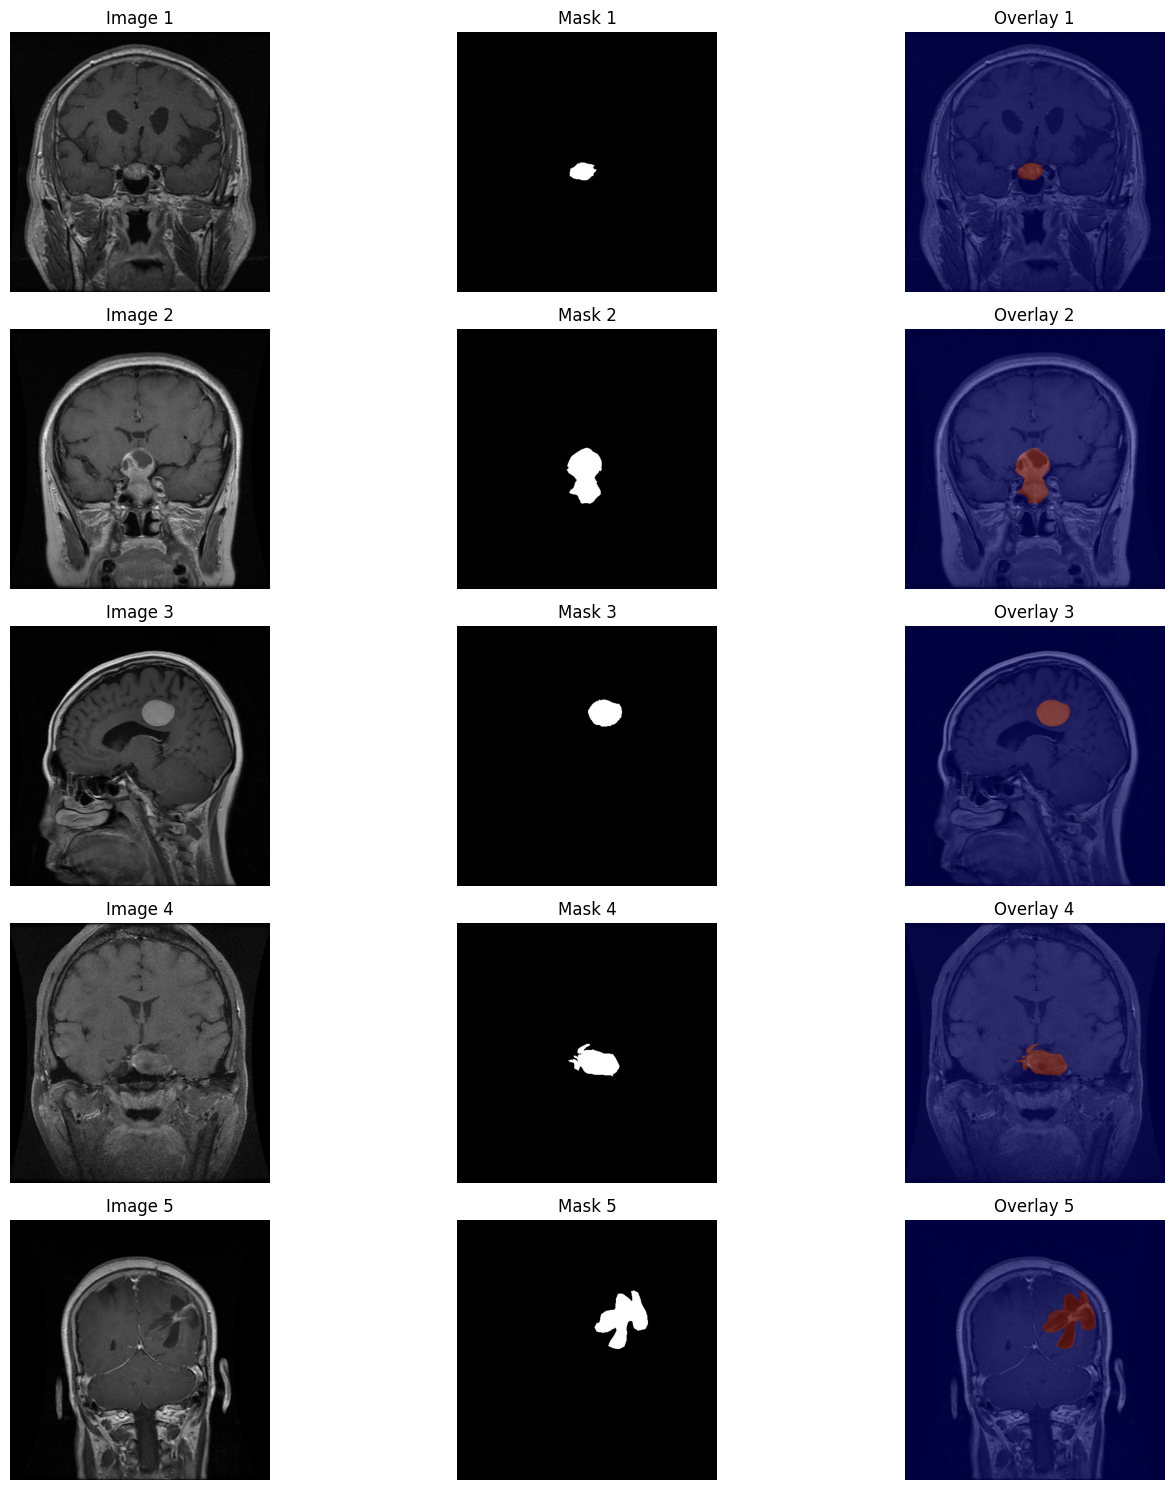

In [6]:
def visualize_samples(df, n_samples=5):
    plt.figure(figsize=(15, 3*n_samples))
    for i in range(min(n_samples, len(df))):
        img = cv2.imread(df['image_path'].iloc[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(df['mask_path'].iloc[i])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        plt.subplot(n_samples, 3, 3*i+1)
        plt.imshow(img)
        plt.title(f'Image {i+1}')
        plt.axis('off')

        plt.subplot(n_samples, 3, 3*i+2)
        plt.imshow(mask)
        plt.title(f'Mask {i+1}')
        plt.axis('off')

        plt.subplot(n_samples, 3, 3*i+3)
        plt.imshow(img)
        plt.imshow(mask[:,:,0], alpha=0.5, cmap='jet')
        plt.title(f'Overlay {i+1}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples(df)

In [7]:
class SegmentationDataset(Dataset):
    def __init__(self, df, transform=None, img_size=256):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        mask_path = self.df.loc[idx, 'mask_path']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (self.img_size, self.img_size))

        # Normalize
        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        # Convert to PyTorch tensors
        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # Add channel dimension

        return img, mask

In [8]:
class ClassificationDataset(Dataset):
    def __init__(self, df, transform=None, img_size=256):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32) / 255.0
        img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)

        return img, torch.tensor(label, dtype=torch.long)


In [9]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = conv_block(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec1 = conv_block(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = conv_block(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = conv_block(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec4 = conv_block(128, 64)

        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder
        dec1 = self.up1(bottleneck)
        dec1 = torch.cat((dec1, enc4), dim=1)
        dec1 = self.dec1(dec1)

        dec2 = self.up2(dec1)
        dec2 = torch.cat((dec2, enc3), dim=1)
        dec2 = self.dec2(dec2)

        dec3 = self.up3(dec2)
        dec3 = torch.cat((dec3, enc2), dim=1)
        dec3 = self.dec3(dec3)

        dec4 = self.up4(dec3)
        dec4 = torch.cat((dec4, enc1), dim=1)
        dec4 = self.dec4(dec4)

        return self.out(dec4)

In [10]:
class UNetWithClassifier(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, num_classes=2):
        super(UNetWithClassifier, self).__init__()

        # Use the same encoder as UNet
        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = conv_block(512, 1024)

        # Decoder for segmentation
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec1 = conv_block(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = conv_block(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = conv_block(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec4 = conv_block(128, 64)
        self.seg_out = nn.Conv2d(64, out_channels, kernel_size=1)

        # Classification head
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        bottleneck = self.bottleneck(self.pool(enc4))

        # Classification from bottleneck
        cls_features = self.global_avg_pool(bottleneck)
        cls_features = cls_features.view(cls_features.size(0), -1)
        classification = self.classifier(cls_features)

        # Decoder for segmentation
        dec1 = self.up1(bottleneck)
        dec1 = torch.cat((dec1, enc4), dim=1)
        dec1 = self.dec1(dec1)

        dec2 = self.up2(dec1)
        dec2 = torch.cat((dec2, enc3), dim=1)
        dec2 = self.dec2(dec2)

        dec3 = self.up3(dec2)
        dec3 = torch.cat((dec3, enc2), dim=1)
        dec3 = self.dec3(dec3)

        dec4 = self.up4(dec3)
        dec4 = torch.cat((dec4, enc1), dim=1)
        dec4 = self.dec4(dec4)

        segmentation = self.seg_out(dec4)

        return segmentation, classification

In [11]:
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

In [22]:
class AttentionUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(AttentionUNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        # Encoder
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.bottleneck = conv_block(512, 1024)

        # Attention blocks
        self.att1 = AttentionBlock(F_g=512, F_l=512, F_int=512)
        self.att2 = AttentionBlock(F_g=256, F_l=256, F_int=256)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=128)
        self.att4 = AttentionBlock(F_g=64, F_l=64, F_int=64)


        # Decoder
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec1 = conv_block(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec2 = conv_block(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = conv_block(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec4 = conv_block(128, 64)

        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder with attention
        dec1 = self.up1(bottleneck)
        att1 = self.att1(g=dec1, x=enc4)
        dec1 = torch.cat((dec1, att1), dim=1)
        dec1 = self.dec1(dec1)

        dec2 = self.up2(dec1)
        att2 = self.att2(g=dec2, x=enc3)
        dec2 = torch.cat((dec2, att2), dim=1)
        dec2 = self.dec2(dec2)

        dec3 = self.up3(dec2)
        att3 = self.att3(g=dec3, x=enc2)
        dec3 = torch.cat((dec3, att3), dim=1)
        dec3 = self.dec3(dec3)

        dec4 = self.up4(dec3)
        att4 = self.att4(g=dec4, x=enc1)
        dec4 = torch.cat((dec4, att4), dim=1)
        dec4 = self.dec4(dec4)

        return self.out(dec4)

In [23]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > 0.5).float()
    intersection = torch.sum(y_true * y_pred)
    union = torch.sum(y_true) + torch.sum(y_pred)
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return dice

In [24]:
def iou_score(y_true, y_pred, smooth=1e-6):
    y_pred = torch.sigmoid(y_pred)
    y_pred = (y_pred > 0.5).float()
    intersection = torch.sum(y_true * y_pred)
    union = torch.sum(y_true) + torch.sum(y_pred) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

In [25]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_score(y_true, y_pred)


In [26]:
def combined_loss(y_true, y_pred, alpha=0.5):
    bce = nn.BCEWithLogitsLoss()(y_pred, y_true)
    dice = dice_loss(y_true, y_pred)
    return alpha * bce + (1 - alpha) * dice


In [28]:
def train_segmentation_model(model, train_loader, val_loader, num_epochs=5, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []
    val_dices = []
    val_ious = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = combined_loss(masks, outputs)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        val_dice = 0.0
        val_iou = 0.0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)

                loss = combined_loss(masks, outputs)
                val_loss += loss.item()
                val_dice += dice_score(masks, outputs).item()
                val_iou += iou_score(masks, outputs).item()

        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        val_dices.append(val_dice / len(val_loader))
        val_ious.append(val_iou / len(val_loader))

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {train_losses[-1]:.4f}')
        print(f'  Val Loss: {val_losses[-1]:.4f}')
        print(f'  Val Dice: {val_dices[-1]:.4f}')
        print(f'  Val IoU: {val_ious[-1]:.4f}')

    return train_losses, val_losses, val_dices, val_ious

In [29]:
def train_combined_model(model, train_loader, val_loader, num_epochs=5, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    seg_criterion = combined_loss
    cls_criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        train_seg_loss = 0.0
        train_cls_loss = 0.0

        for images, (masks, labels) in train_loader:
            images, masks, labels = images.to(device), masks.to(device), labels.to(device)

            optimizer.zero_grad()
            seg_outputs, cls_outputs = model(images)

            seg_loss = seg_criterion(masks, seg_outputs)
            cls_loss = cls_criterion(cls_outputs, labels)
            total_loss = seg_loss + cls_loss

            total_loss.backward()
            optimizer.step()

            train_seg_loss += seg_loss.item()
            train_cls_loss += cls_loss.item()

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Seg Loss: {train_seg_loss/len(train_loader):.4f}')
        print(f'  Cls Loss: {train_cls_loss/len(train_loader):.4f}')


In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [31]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

train_seg_dataset = SegmentationDataset(train_df)
val_seg_dataset = SegmentationDataset(val_df)
train_cls_dataset = ClassificationDataset(train_df)
val_cls_dataset = ClassificationDataset(val_df)

train_seg_loader = DataLoader(train_seg_dataset, batch_size=8, shuffle=True)
val_seg_loader = DataLoader(val_seg_dataset, batch_size=8, shuffle=False)
train_cls_loader = DataLoader(train_cls_dataset, batch_size=8, shuffle=True)
val_cls_loader = DataLoader(val_cls_dataset, batch_size=8, shuffle=False)

In [32]:
print("TRAINING U-NET FOR SEGMENTATION")
unet_model = UNet()
unet_losses = train_segmentation_model(unet_model, train_seg_loader, val_seg_loader, num_epochs=5)

TRAINING U-NET FOR SEGMENTATION
Epoch 1/5:
  Train Loss: 0.4683
  Val Loss: 0.2599
  Val Dice: 0.5341
  Val IoU: 0.3725
Epoch 2/5:
  Train Loss: 0.2465
  Val Loss: 0.2034
  Val Dice: 0.6293
  Val IoU: 0.4703
Epoch 3/5:
  Train Loss: 0.1982
  Val Loss: 0.1883
  Val Dice: 0.6545
  Val IoU: 0.5003
Epoch 4/5:
  Train Loss: 0.1791
  Val Loss: 0.1947
  Val Dice: 0.6386
  Val IoU: 0.4852
Epoch 5/5:
  Train Loss: 0.1618
  Val Loss: 0.2529
  Val Dice: 0.5307
  Val IoU: 0.3763


In [33]:
print("TRAINING ATTENTION U-NET FOR SEGMENTATION")
attention_unet_model = AttentionUNet()
attention_losses = train_segmentation_model(attention_unet_model, train_seg_loader, val_seg_loader, num_epochs=5)

TRAINING ATTENTION U-NET FOR SEGMENTATION
Epoch 1/5:
  Train Loss: 0.3713
  Val Loss: 0.2878
  Val Dice: 0.4740
  Val IoU: 0.3205
Epoch 2/5:
  Train Loss: 0.2409
  Val Loss: 0.2382
  Val Dice: 0.5682
  Val IoU: 0.4125
Epoch 3/5:
  Train Loss: 0.1941
  Val Loss: 0.1672
  Val Dice: 0.6941
  Val IoU: 0.5426
Epoch 4/5:
  Train Loss: 0.1674
  Val Loss: 0.1688
  Val Dice: 0.6903
  Val IoU: 0.5419
Epoch 5/5:
  Train Loss: 0.1521
  Val Loss: 0.1582
  Val Dice: 0.7091
  Val IoU: 0.5586


U-NET SEGMENTATION RESULTS


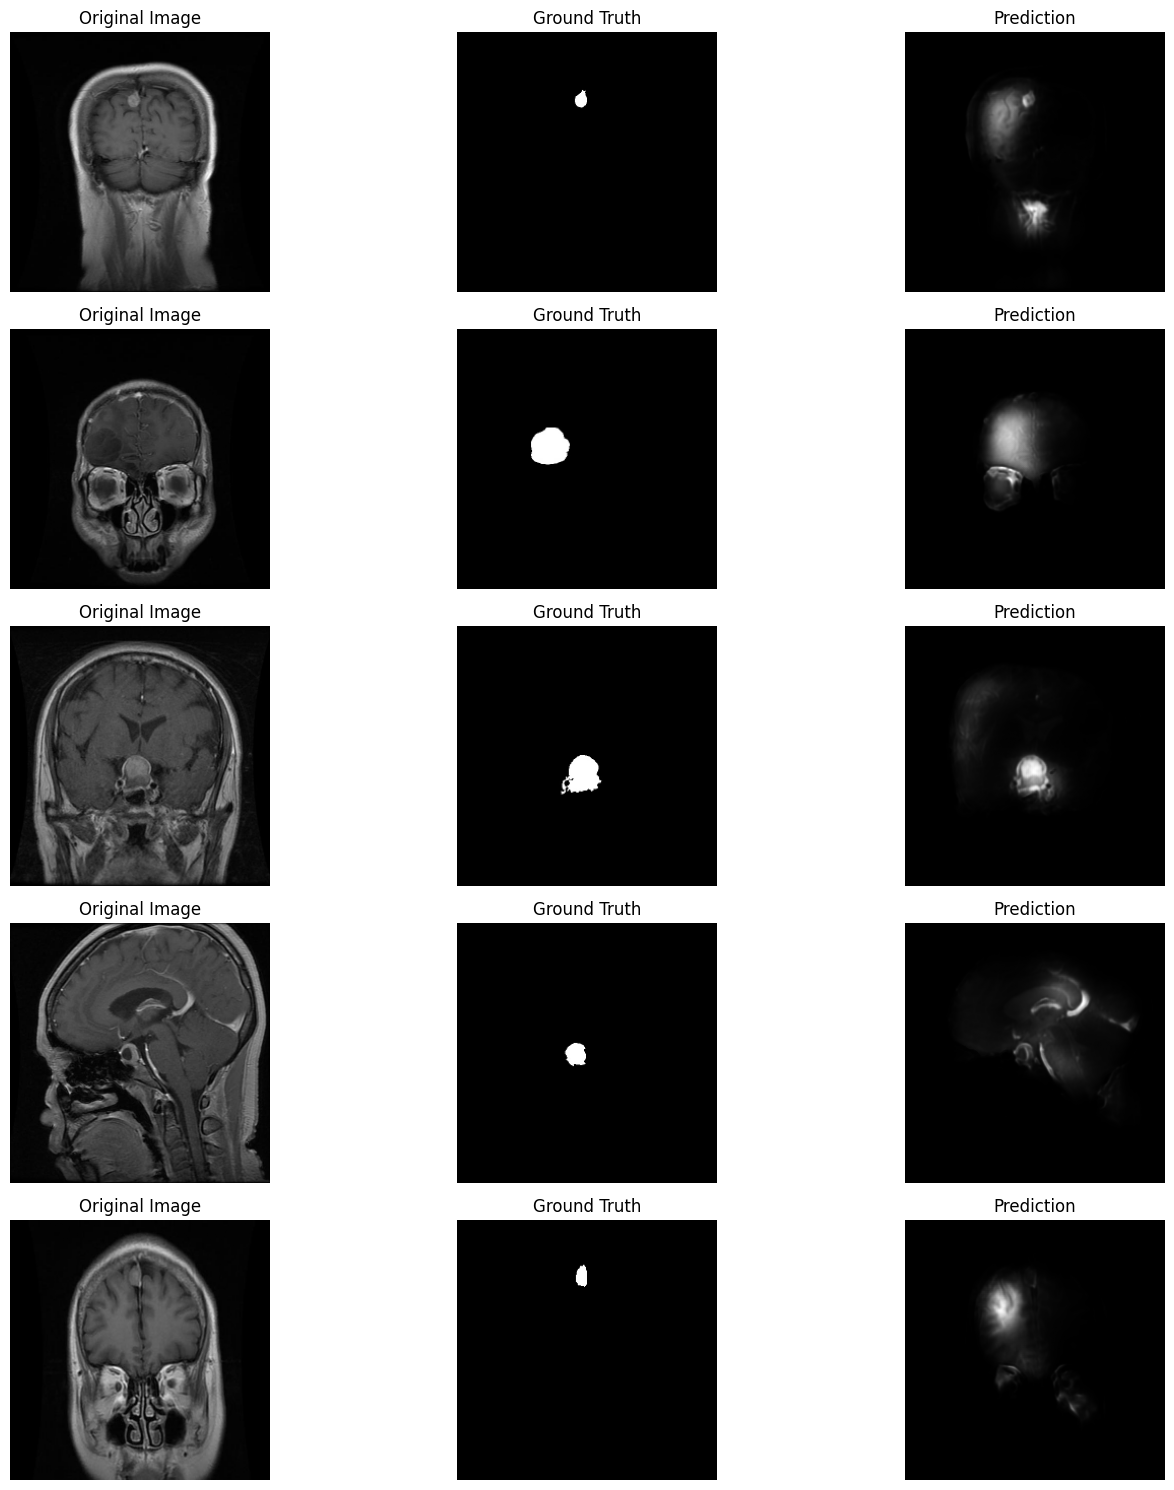

ATTENTION U-NET SEGMENTATION RESULTS


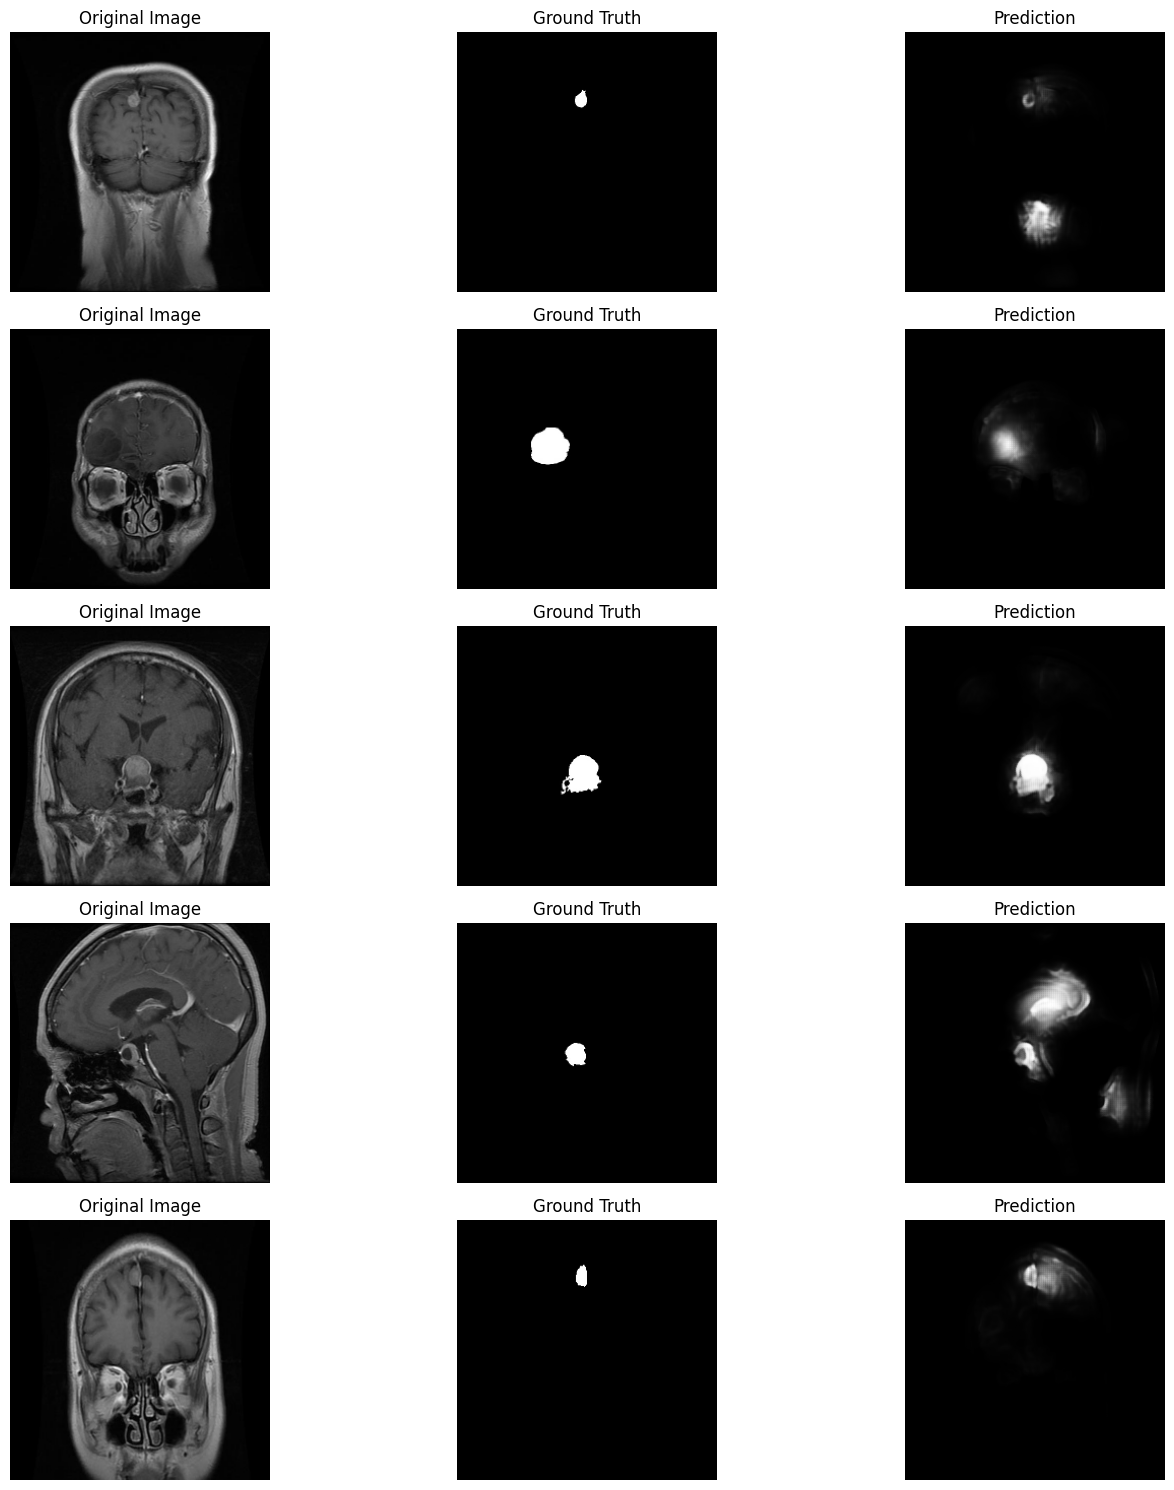

In [34]:
def visualize_results(model, dataset, n_samples=5):
    model.eval()

    plt.figure(figsize=(15, 3*n_samples))
    for i in range(min(n_samples, len(dataset))):
        img, mask = dataset[i]
        img_input = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(img_input)
            pred = torch.sigmoid(pred).squeeze().cpu().numpy()
        #numpy visualaization
        img_np = img.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()

        plt.subplot(n_samples, 3, 3*i+1)
        plt.imshow(img_np)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(n_samples, 3, 3*i+2)
        plt.imshow(mask_np, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')

        plt.subplot(n_samples, 3, 3*i+3)
        plt.imshow(pred, cmap='gray')
        plt.title('Prediction')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("U-NET SEGMENTATION RESULTS")
visualize_results(unet_model, val_seg_dataset)

print("ATTENTION U-NET SEGMENTATION RESULTS")
visualize_results(attention_unet_model, val_seg_dataset)


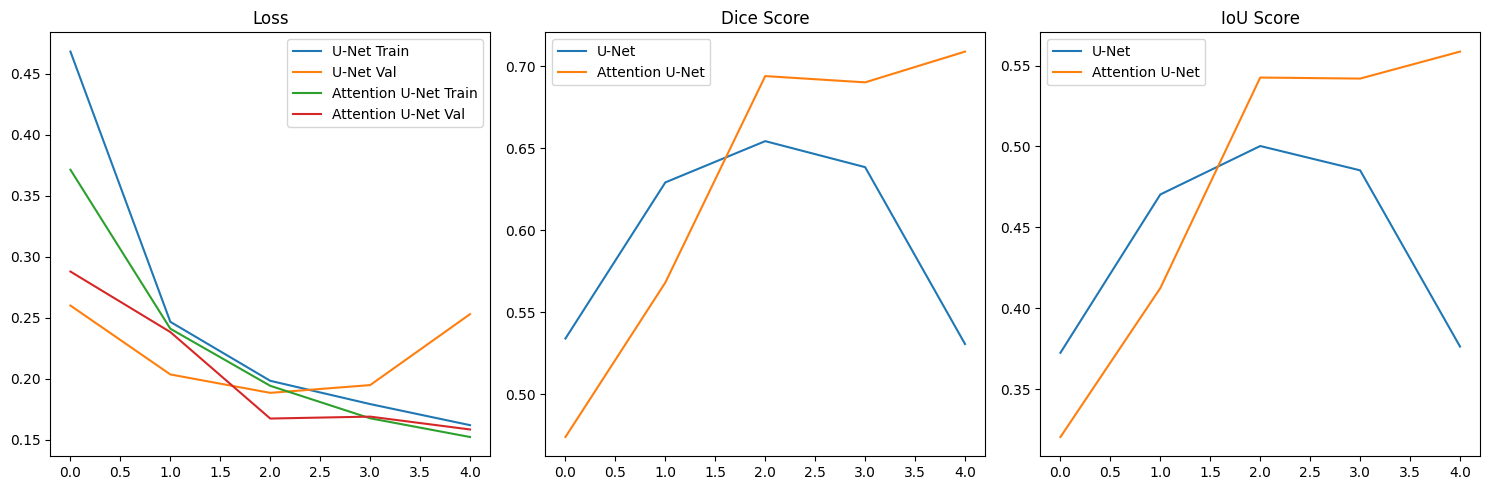

In [35]:
def plot_training_curves(losses1, losses2, title1="U-Net", title2="Attention U-Net"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].plot(losses1[0], label=f'{title1} Train')
    axes[0].plot(losses1[1], label=f'{title1} Val')
    axes[0].plot(losses2[0], label=f'{title2} Train')
    axes[0].plot(losses2[1], label=f'{title2} Val')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(losses1[2], label=f'{title1}')
    axes[1].plot(losses2[2], label=f'{title2}')
    axes[1].set_title('Dice Score')
    axes[1].legend()

    axes[2].plot(losses1[3], label=f'{title1}')
    axes[2].plot(losses2[3], label=f'{title2}')
    axes[2].set_title('IoU Score')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(unet_losses, attention_losses)

Bonus tasks

Separate vs Joint Training Analysis
Epoch 1/5:
  Train Loss: 0.4386
  Val Loss: 0.3190
  Val Dice: 0.4274
  Val IoU: 0.2773
Epoch 2/5:
  Train Loss: 0.2466
  Val Loss: 0.2414
  Val Dice: 0.5545
  Val IoU: 0.4003
Epoch 3/5:
  Train Loss: 0.2119
  Val Loss: 0.2506
  Val Dice: 0.5347
  Val IoU: 0.3803
Epoch 4/5:
  Train Loss: 0.1895
  Val Loss: 0.1848
  Val Dice: 0.6625
  Val IoU: 0.5080
Epoch 5/5:
  Train Loss: 0.1699
  Val Loss: 0.1618
  Val Dice: 0.7036
  Val IoU: 0.5529
Separate Segmentation - Final Dice: 0.7036, IoU: 0.5529
Epoch 2: Loss=0.6931, Acc=0.5070
Epoch 4: Loss=0.6934, Acc=0.5070
Separate Classification - Final Accuracy: 0.5070
Epoch 2: Seg_Loss=0.2932, Cls_Loss=0.6942, Dice=0.2470, Acc=0.5070
Epoch 4: Seg_Loss=0.1976, Cls_Loss=0.6932, Dice=0.6608, Acc=0.5108
Joint Training - Final Dice: 0.6469, IoU: 0.4939, Acc: 0.5070
        Training Method Segmentation Dice Segmentation IoU Classification Accuracy Training Time (s)
  Separate Segmentation          0.703553           0.55

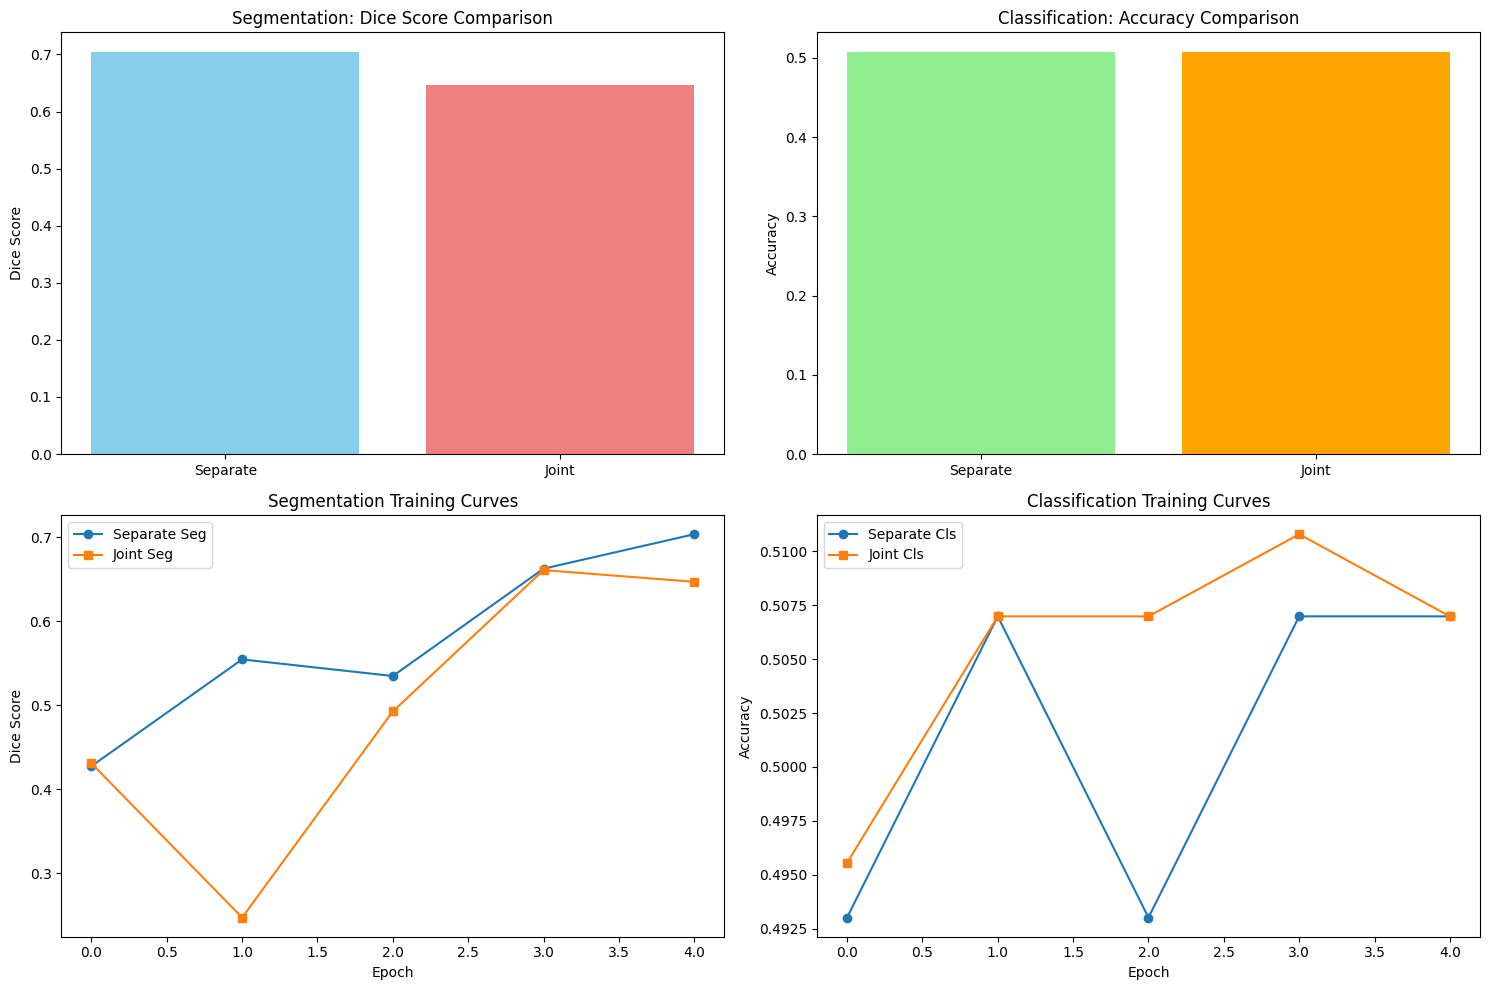

In [36]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import time
class SeparateTrainingAnalysis:
    def __init__(self, train_seg_loader, val_seg_loader, train_cls_loader, val_cls_loader, device):
        self.train_seg_loader = train_seg_loader
        self.val_seg_loader = val_seg_loader
        self.train_cls_loader = train_cls_loader
        self.val_cls_loader = val_cls_loader
        self.device = device
        self.results = {}

    def train_segmentation_only(self, epochs=5):
        model = UNet().to(self.device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        start_time = time.time()
        train_losses, val_losses, val_dices, val_ious = train_segmentation_model(
            model, self.train_seg_loader, self.val_seg_loader, epochs, lr=0.001
        )
        training_time = time.time() - start_time

        self.results['separate_segmentation'] = {
            'model': model,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_dices': val_dices,
            'val_ious': val_ious,
            'final_dice': val_dices[-1],
            'final_iou': val_ious[-1],
            'training_time': training_time
        }

        print(f"Separate Segmentation - Final Dice: {val_dices[-1]:.4f}, IoU: {val_ious[-1]:.4f}")
        return model

    def train_classification_only(self, epochs=5):
        class SimpleCNNClassifier(nn.Module):
            def __init__(self, num_classes=2):
                super().__init__()
                self.features = nn.Sequential(
                    nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                    nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
                )
                self.classifier = nn.Sequential(
                    nn.Flatten(),
                    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
                    nn.Linear(256, num_classes)
                )
            def forward(self, x):
                return self.classifier(self.features(x))

        model = SimpleCNNClassifier().to(self.device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        start_time = time.time()
        train_losses, val_accuracies = [], []

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            for images, labels in self.train_cls_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

#evaluation
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for images, labels in self.val_cls_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = model(images)
                    preds = torch.argmax(outputs, dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            accuracy = accuracy_score(all_labels, all_preds)
            train_losses.append(train_loss / len(self.train_cls_loader))
            val_accuracies.append(accuracy)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={accuracy:.4f}")

        training_time = time.time() - start_time

#metrices eva
        f1 = f1_score(all_labels, all_preds, average='weighted')
        precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

        self.results['separate_classification'] = {
            'model': model,
            'train_losses': train_losses,
            'val_accuracies': val_accuracies,
            'final_accuracy': val_accuracies[-1],
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'training_time': training_time
        }

        print(f"Separate Classification - Final Accuracy: {val_accuracies[-1]:.4f}")
        return model

    def train_joint_model(self, epochs=5):
        class CombinedDataset(Dataset):
            def __init__(self, df, img_size=256):
                self.df = df.reset_index(drop=True)
                self.img_size = img_size

            def __len__(self):
                return len(self.df)

            def __getitem__(self, idx):
                img_path = self.df.loc[idx, 'image_path']
                mask_path = self.df.loc[idx, 'mask_path']
                label = self.df.loc[idx, 'label']

                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (self.img_size, self.img_size))

                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.resize(mask, (self.img_size, self.img_size))

                img = img.astype(np.float32) / 255.0
                mask = mask.astype(np.float32) / 255.0

                img = torch.tensor(img.transpose(2, 0, 1), dtype=torch.float32)
                mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
                label = torch.tensor(label, dtype=torch.long)

                return img, mask, label


        train_combined = CombinedDataset(train_df)
        val_combined = CombinedDataset(val_df)
        train_combined_loader = DataLoader(train_combined, batch_size=8, shuffle=True)
        val_combined_loader = DataLoader(val_combined, batch_size=8, shuffle=False)

        model = UNetWithClassifier().to(self.device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
        seg_criterion = combined_loss
        cls_criterion = nn.CrossEntropyLoss()

        start_time = time.time()
        train_seg_losses, train_cls_losses = [], []
        val_dices, val_ious, val_accuracies = [], [], []

        for epoch in range(epochs):
            model.train()
            train_seg_loss = 0.0
            train_cls_loss = 0.0

            for images, masks, labels in train_combined_loader:
                images = images.to(self.device)
                masks = masks.to(self.device)
                labels = labels.to(self.device)

                optimizer.zero_grad()
                seg_outputs, cls_outputs = model(images)

                seg_loss = seg_criterion(masks, seg_outputs)
                cls_loss = cls_criterion(cls_outputs, labels)
                total_loss = seg_loss + 0.5 * cls_loss

                total_loss.backward()
                optimizer.step()

                train_seg_loss += seg_loss.item()
                train_cls_loss += cls_loss.item()

            model.eval()
            val_seg_loss = 0.0
            val_dice = 0.0
            val_iou = 0.0
            all_preds, all_labels = [], []

            with torch.no_grad():
                for images, masks, labels in val_combined_loader:
                    images = images.to(self.device)
                    masks = masks.to(self.device)
                    labels = labels.to(self.device)

                    seg_outputs, cls_outputs = model(images)

                    val_dice += dice_score(masks, seg_outputs).item()
                    val_iou += iou_score(masks, seg_outputs).item()

                    preds = torch.argmax(cls_outputs, dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            accuracy = accuracy_score(all_labels, all_preds)

            train_seg_losses.append(train_seg_loss / len(train_combined_loader))
            train_cls_losses.append(train_cls_loss / len(train_combined_loader))
            val_dices.append(val_dice / len(val_combined_loader))
            val_ious.append(val_iou / len(val_combined_loader))
            val_accuracies.append(accuracy)

            if (epoch + 1) % 2 == 0:
                print(f"Epoch {epoch+1}: Seg_Loss={train_seg_losses[-1]:.4f}, "
                      f"Cls_Loss={train_cls_losses[-1]:.4f}, Dice={val_dices[-1]:.4f}, Acc={accuracy:.4f}")

        training_time = time.time() - start_time

        f1 = f1_score(all_labels, all_preds, average='weighted')
        precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

        self.results['joint_training'] = {
            'model': model,
            'train_seg_losses': train_seg_losses,
            'train_cls_losses': train_cls_losses,
            'val_dices': val_dices,
            'val_ious': val_ious,
            'val_accuracies': val_accuracies,
            'final_dice': val_dices[-1],
            'final_iou': val_ious[-1],
            'final_accuracy': val_accuracies[-1],
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'training_time': training_time
        }

        print(f"Joint Training - Final Dice: {val_dices[-1]:.4f}, IoU: {val_ious[-1]:.4f}, Acc: {val_accuracies[-1]:.4f}")
        return model

    def compare_and_analyze(self):
        comparison_data = {
            'Training Method': ['Separate Segmentation', 'Separate Classification', 'Joint Training'],
            'Segmentation Dice': [
                self.results['separate_segmentation']['final_dice'],
                'N/A',
                self.results['joint_training']['final_dice']
            ],
            'Segmentation IoU': [
                self.results['separate_segmentation']['final_iou'],
                'N/A',
                self.results['joint_training']['final_iou']
            ],
            'Classification Accuracy': [
                'N/A',
                self.results['separate_classification']['final_accuracy'],
                self.results['joint_training']['final_accuracy']
            ],
            'Training Time (s)': [
                f"{self.results['separate_segmentation']['training_time']:.1f}",
                f"{self.results['separate_classification']['training_time']:.1f}",
                f"{self.results['joint_training']['training_time']:.1f}"
            ]
        }

        df_comparison = pd.DataFrame(comparison_data)
        print(df_comparison.to_string(index=False))

        print(f"\nANALYSIS:")
        print(f"Separate Segmentation vs Joint Segmentation:")
        dice_diff = self.results['joint_training']['final_dice'] - self.results['separate_segmentation']['final_dice']
        iou_diff = self.results['joint_training']['final_iou'] - self.results['separate_segmentation']['final_iou']
        print(f"   Dice Score Difference: {dice_diff:+.4f}")
        print(f"   IoU Score Difference: {iou_diff:+.4f}")

        print(f"\nSeparate Classification vs Joint Classification:")
        acc_diff = self.results['joint_training']['final_accuracy'] - self.results['separate_classification']['final_accuracy']
        print(f"   Accuracy Difference: {acc_diff:+.4f}")

        total_separate_time = (self.results['separate_segmentation']['training_time'] +
                              self.results['separate_classification']['training_time'])
        joint_time = self.results['joint_training']['training_time']
        time_efficiency = (total_separate_time - joint_time) / total_separate_time * 100

        print(f"\nTIME EFFICIENCY:")
        print(f"   Total Separate Training: {total_separate_time:.1f}s")
        print(f"   Joint Training: {joint_time:.1f}s")
        print(f"   Time Saved: {time_efficiency:.1f}%")
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

#segmentation comparison
        axes[0,0].bar(['Separate', 'Joint'],
                     [self.results['separate_segmentation']['final_dice'],
                      self.results['joint_training']['final_dice']],
                     color=['skyblue', 'lightcoral'])
        axes[0,0].set_title('Segmentation: Dice Score Comparison')
        axes[0,0].set_ylabel('Dice Score')

        axes[0,1].bar(['Separate', 'Joint'],
                     [self.results['separate_classification']['final_accuracy'],
                      self.results['joint_training']['final_accuracy']],
                     color=['lightgreen', 'orange'])
        axes[0,1].set_title('Classification: Accuracy Comparison')
        axes[0,1].set_ylabel('Accuracy')

#curves from training
        axes[1,0].plot(self.results['separate_segmentation']['val_dices'],
                      label='Separate Seg', marker='o')
        axes[1,0].plot(self.results['joint_training']['val_dices'],
                      label='Joint Seg', marker='s')
        axes[1,0].set_title('Segmentation Training Curves')
        axes[1,0].set_xlabel('Epoch')
        axes[1,0].set_ylabel('Dice Score')
        axes[1,0].legend()

        axes[1,1].plot(self.results['separate_classification']['val_accuracies'],
                      label='Separate Cls', marker='o')
        axes[1,1].plot(self.results['joint_training']['val_accuracies'],
                      label='Joint Cls', marker='s')
        axes[1,1].set_title('Classification Training Curves')
        axes[1,1].set_xlabel('Epoch')
        axes[1,1].set_ylabel('Accuracy')
        axes[1,1].legend()

        plt.tight_layout()
        plt.show()

        return df_comparison
print("Separate vs Joint Training Analysis")
analyzer = SeparateTrainingAnalysis(train_seg_loader, val_seg_loader,
                                  train_cls_loader, val_cls_loader, device)

seg_model = analyzer.train_segmentation_only(epochs=5)
cls_model = analyzer.train_classification_only(epochs=5)
joint_model = analyzer.train_joint_model(epochs=5)

comparison_results = analyzer.compare_and_analyze()

In [38]:
class ClassifierComparison:
    def __init__(self, train_loader, val_loader, device):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.results = {}

    class SimpleCNN(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                nn.AdaptiveAvgPool2d(1)
            )
            self.classifier = nn.Sequential(
                nn.Flatten(), nn.Linear(128, 64), nn.ReLU(),
                nn.Dropout(0.5), nn.Linear(64, num_classes)
            )
        def forward(self, x):
            return self.classifier(self.features(x))

    class ResNetBlock(nn.Module):
        def __init__(self, in_channels, out_channels, stride=1):
            super().__init__()
            self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
            self.bn1 = nn.BatchNorm2d(out_channels)
            self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
            self.bn2 = nn.BatchNorm2d(out_channels)
            self.relu = nn.ReLU(inplace=True)

            self.shortcut = nn.Sequential()
            if stride != 1 or in_channels != out_channels:
                self.shortcut = nn.Sequential(
                    nn.Conv2d(in_channels, out_channels, 1, stride),
                    nn.BatchNorm2d(out_channels)
                )

        def forward(self, x):
            residual = self.shortcut(x)
            out = self.relu(self.bn1(self.conv1(x)))
            out = self.bn2(self.conv2(out))
            out += residual
            return self.relu(out)

    class CustomResNet(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 64, 7, 2, 3)
            self.bn1 = nn.BatchNorm2d(64)
            self.relu = nn.ReLU(inplace=True)
            self.maxpool = nn.MaxPool2d(3, 2, 1)

            self.layer1 = self._make_layer(64, 64, 2, 1)
            self.layer2 = self._make_layer(64, 128, 2, 2)
            self.layer3 = self._make_layer(128, 256, 2, 2)

            self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = nn.Linear(256, num_classes)

        def _make_layer(self, in_channels, out_channels, blocks, stride):
            layers = [ClassifierComparison.ResNetBlock(in_channels, out_channels, stride)]
            for _ in range(1, blocks):
                layers.append(ClassifierComparison.ResNetBlock(out_channels, out_channels))
            return nn.Sequential(*layers)

        def forward(self, x):
            x = self.relu(self.bn1(self.conv1(x)))
            x = self.maxpool(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)
            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            return self.fc(x)

    class VGGInspired(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.features = nn.Sequential(
                # Block 1
                nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(True),
                nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(True),
                nn.MaxPool2d(2, 2),
                # Block 2
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True),
                nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(True),
                nn.MaxPool2d(2, 2),
                # Block 3
                nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True),
                nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True),
                nn.MaxPool2d(2, 2),
                # Block 4
                nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(True),
                nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True),
                nn.AdaptiveAvgPool2d((7, 7))
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(512 * 7 * 7, 4096), nn.ReLU(True), nn.Dropout(0.5),
                nn.Linear(4096, 1024), nn.ReLU(True), nn.Dropout(0.5),
                nn.Linear(1024, num_classes)
            )

        def forward(self, x):
            return self.classifier(self.features(x))

    class DepthwiseSeparableConv(nn.Module):
        def __init__(self, in_channels, out_channels, stride=1):
            super().__init__()
            self.depthwise = nn.Conv2d(in_channels, in_channels, 3, stride, 1, groups=in_channels)
            self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0)
            self.bn1 = nn.BatchNorm2d(in_channels)
            self.bn2 = nn.BatchNorm2d(out_channels)
            self.relu = nn.ReLU6(inplace=True)

        def forward(self, x):
            x = self.relu(self.bn1(self.depthwise(x)))
            x = self.relu(self.bn2(self.pointwise(x)))
            return x

    class MobileNetInspired(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.conv1 = nn.Conv2d(3, 32, 3, 2, 1)
            self.bn1 = nn.BatchNorm2d(32)
            self.relu = nn.ReLU6(inplace=True)

            self.layers = nn.Sequential(
                ClassifierComparison.DepthwiseSeparableConv(32, 64, 1),
                ClassifierComparison.DepthwiseSeparableConv(64, 128, 2),
                ClassifierComparison.DepthwiseSeparableConv(128, 128, 1),
                ClassifierComparison.DepthwiseSeparableConv(128, 256, 2),
                ClassifierComparison.DepthwiseSeparableConv(256, 256, 1),
                ClassifierComparison.DepthwiseSeparableConv(256, 512, 2),
            )

            self.avgpool = nn.AdaptiveAvgPool2d(1)
            self.fc = nn.Linear(512, num_classes)

        def forward(self, x):
            x = self.relu(self.bn1(self.conv1(x)))
            x = self.layers(x)
            x = self.avgpool(x)
            x = x.view(x.size(0), -1)
            return self.fc(x)

    class AttentionCNN(nn.Module):
        def __init__(self, num_classes=2):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
                nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
                nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
                nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            )

            self.channel_attention = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),
                nn.Conv2d(256, 256 // 16, 1), nn.ReLU(),
                nn.Conv2d(256 // 16, 256, 1), nn.Sigmoid()
            )
            self.spatial_attention = nn.Sequential(
                nn.Conv2d(2, 1, 7, padding=3), nn.Sigmoid()
            )
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
                nn.Linear(128, num_classes)
            )
        def forward(self, x):
            features = self.features(x)

            ca = self.channel_attention(features)
            features = features * ca

            avg_pool = torch.mean(features, dim=1, keepdim=True)
            max_pool, _ = torch.max(features, dim=1, keepdim=True)
            spatial_input = torch.cat([avg_pool, max_pool], dim=1)
            sa = self.spatial_attention(spatial_input)
            features = features * sa

            return self.classifier(features)

    def train_and_evaluate(self, model, model_name, epochs=5, lr=0.001):
        model = model.to(self.device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)

        train_losses, val_accuracies = [], []
        train_accuracies = []
        best_accuracy = 0.0
        start_time = time.time()

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                train_total += labels.size(0)
                train_correct += (predicted == labels).sum().item()

            scheduler.step()
            model.eval()
            val_correct = 0
            val_total = 0
            all_preds, all_labels = [], []

            with torch.no_grad():
                for images, labels in self.val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels

ADAM
  LR 0.1: Best Acc = 0.5070
  LR 0.01: Best Acc = 0.5070
  LR 0.001: Best Acc = 0.5108
  LR 0.0001: Best Acc = 0.5070
SGD
  LR 0.1: Best Acc = 0.5070
  LR 0.01: Best Acc = 0.5070
  LR 0.001: Best Acc = 0.5070
  LR 0.0001: Best Acc = 0.4930
RMSPROP
  LR 0.1: Best Acc = 0.5070
  LR 0.01: Best Acc = 0.5070
  LR 0.001: Best Acc = 0.5070
  LR 0.0001: Best Acc = 0.5070
ADAMW
  LR 0.1: Best Acc = 0.5070
  LR 0.01: Best Acc = 0.5070
  LR 0.001: Best Acc = 0.5070
  LR 0.0001: Best Acc = 0.5159


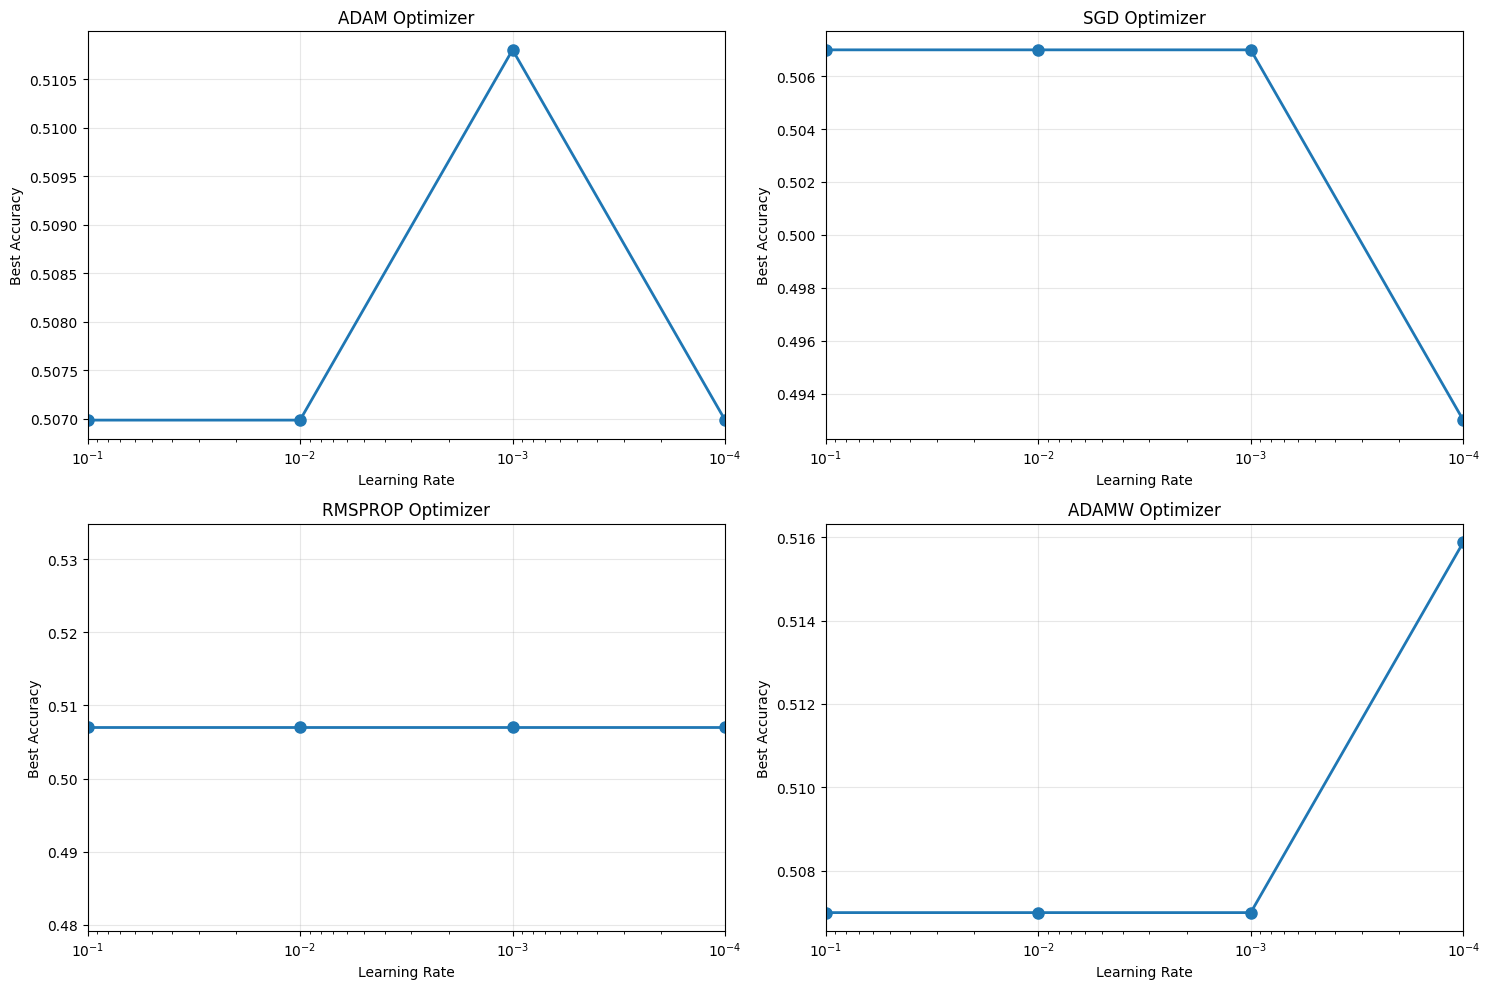

Optimizer  Best LR Best Accuracy Training Time (s)
     ADAM   0.0010        0.5108              74.6
      SGD   0.1000        0.5070              74.1
  RMSPROP   0.1000        0.5070              72.8
    ADAMW   0.0001        0.5159              74.4
  Best Accuracy: 0.5159
  Best Accuracy: 0.5172
  Best Accuracy: 0.5172
  Best Accuracy: 0.5070


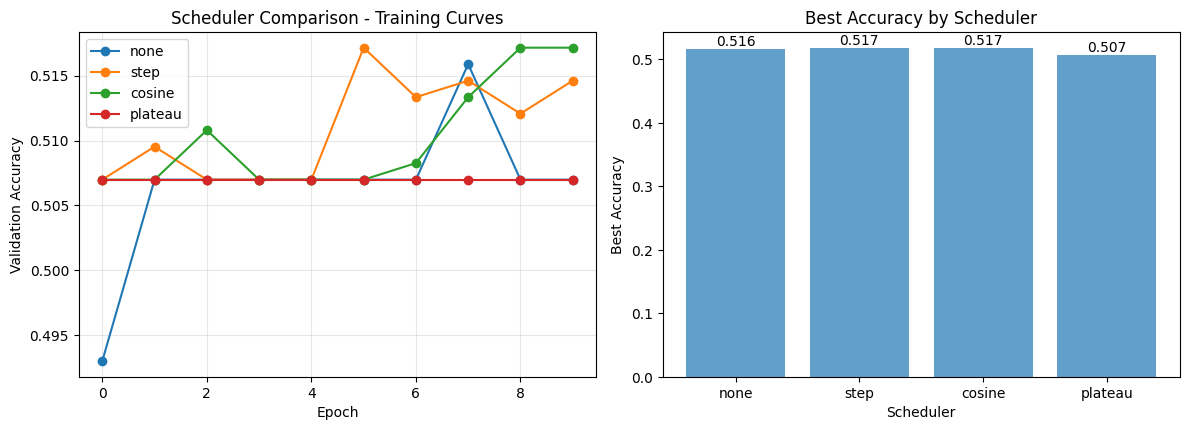

Total combinations to test: 64

Testing combination 1/64
Config: {'architecture': 'simple', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0001, 'scheduler': 'step', 'grad_clip': 0, 'momentum': 0}
   Result: Best Acc = 0.5070

Testing combination 2/64
Config: {'architecture': 'simple', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0001, 'scheduler': 'step', 'grad_clip': 1.0, 'momentum': 0}
   Result: Best Acc = 0.5070

Testing combination 3/64
Config: {'architecture': 'simple', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0001, 'scheduler': 'cosine', 'grad_clip': 0, 'momentum': 0}
   Result: Best Acc = 0.5070

Testing combination 4/64
Config: {'architecture': 'simple', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.0001, 'scheduler': 'cosine', 'grad_clip': 1.0, 'momentum': 0}
   Result: Best Acc = 0.5070

Testing combination 5/64
Config: {'architecture': 'simple', 'optimizer': 'adam', 'lr': 0.01, 'weight_decay': 0.001, 'scheduler': 'step', 'grad_clip': 0, 'momentum':

In [ ]:
import itertools
from collections import defaultdict

class HyperparameterOptimizer:
    def __init__(self, train_loader, val_loader, device):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.results = defaultdict(list)
        self.best_configs = {}

    def create_model(self, architecture='simple'):
        if architecture == 'simple':
            return ClassifierComparison.SimpleCNN()
        elif architecture == 'resnet':
            return ClassifierComparison.CustomResNet()
        elif architecture == 'attention':
            return ClassifierComparison.AttentionCNN()
        else:
            return UNet()

    def train_with_config(self, config, epochs=5):
        model = self.create_model(config['architecture']).to(self.device)
        if config['optimizer'] == 'adam':
            optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                       weight_decay=config['weight_decay'])
        elif config['optimizer'] == 'sgd':
            optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'],
                                      momentum=config['momentum'],
                                      weight_decay=config['weight_decay'])
        elif config['optimizer'] == 'rmsprop':
            optimizer = torch.optim.RMSprop(model.parameters(), lr=config['lr'],
                                          weight_decay=config['weight_decay'])
        elif config['optimizer'] == 'adamw':
            optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                        weight_decay=config['weight_decay'])

        if config['scheduler'] == 'step':
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)
        elif config['scheduler'] == 'cosine':
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        elif config['scheduler'] == 'plateau':
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
        else:
            scheduler = None

        criterion = nn.CrossEntropyLoss()

        train_losses, val_accuracies = [], []
        best_accuracy = 0.0
        start_time = time.time()

        for epoch in range(epochs):
            model.train()
            train_loss = 0.0

            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()

                if config['grad_clip'] > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), config['grad_clip'])

                optimizer.step()
                train_loss += loss.item()
            model.eval()
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for images, labels in self.val_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            val_acc = val_correct / val_total
            train_losses.append(train_loss / len(self.train_loader))
            val_accuracies.append(val_acc)

            if val_acc > best_accuracy:
                best_accuracy = val_acc

            if scheduler is not None:
                if config['scheduler'] == 'plateau':
                    scheduler.step(val_acc)
                else:
                    scheduler.step()

        training_time = time.time() - start_time

        return {
            'best_accuracy': best_accuracy,
            'final_accuracy': val_accuracies[-1],
            'training_time': training_time,
            'train_losses': train_losses,
            'val_accuracies': val_accuracies,
            'config': config
        }

    def optimizer_study(self):
        optimizers = ['adam', 'sgd', 'rmsprop', 'adamw']
        learning_rates = [0.1, 0.01, 0.001, 0.0001]

        optimizer_results = {}

        for optimizer in optimizers:
            print(optimizer.upper())
            opt_results = []

            for lr in learning_rates:
                config = {
                    'architecture': 'simple',
                    'optimizer': optimizer,
                    'lr': lr,
                    'weight_decay': 1e-4,
                    'momentum': 0.9 if optimizer == 'sgd' else 0,
                    'scheduler': 'none',
                    'grad_clip': 0
                }

                result = self.train_with_config(config)
                opt_results.append(result)
                print(f"  LR {lr}: Best Acc = {result['best_accuracy']:.4f}")

            optimizer_results[optimizer] = opt_results

            best_result = max(opt_results, key=lambda x: x['best_accuracy'])
            self.best_configs[f'best_{optimizer}'] = best_result

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        for i, (opt_name, results) in enumerate(optimizer_results.items()):
            ax = axes[i//2, i%2]

            accuracies = [r['best_accuracy'] for r in results]
            ax.semilogx(learning_rates, accuracies, 'o-', linewidth=2, markersize=8)
            ax.set_xlabel('Learning Rate')
            ax.set_ylabel('Best Accuracy')
            ax.set_title(f'{opt_name.upper()} Optimizer')
            ax.grid(True, alpha=0.3)
            ax.set_xlim(max(learning_rates), min(learning_rates))

        plt.tight_layout()
        plt.show()
        summary_data = {
            'Optimizer': [],
            'Best LR': [],
            'Best Accuracy': [],
            'Training Time (s)': []
        }
        for opt_name, result in self.best_configs.items():
            if opt_name.startswith('best_'):
                optimizer_name = opt_name.replace('best_', '').upper()
                summary_data['Optimizer'].append(optimizer_name)
                summary_data['Best LR'].append(result['config']['lr'])
                summary_data['Best Accuracy'].append(f"{result['best_accuracy']:.4f}")
                summary_data['Training Time (s)'].append(f"{result['training_time']:.1f}")

        df_optimizer = pd.DataFrame(summary_data)
        print(df_optimizer.to_string(index=False))

        return optimizer_results

    def scheduler_study(self):
        schedulers = ['none', 'step', 'cosine', 'plateau']
        scheduler_results = {}

        best_opt_config = max(self.best_configs.values(), key=lambda x: x['best_accuracy'])
        base_config = best_opt_config['config'].copy()

        for scheduler in schedulers:
            config = base_config.copy()
            config['scheduler'] = scheduler

            result = self.train_with_config(config, epochs=10)
            scheduler_results[scheduler] = result

            print(f"  Best Accuracy: {result['best_accuracy']:.4f}")

        best_scheduler_result = max(scheduler_results.values(), key=lambda x: x['best_accuracy'])
        self.best_configs['best_scheduler'] = best_scheduler_result
        plt.figure(figsize=(12, 8))

        plt.subplot(2, 2, 1)
        for scheduler, result in scheduler_results.items():
            plt.plot(result['val_accuracies'], label=f'{scheduler}', marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Validation Accuracy')
        plt.title('Scheduler Comparison - Training Curves')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(2, 2, 2)
        schedulers_list = list(scheduler_results.keys())
        final_accs = [scheduler_results[s]['best_accuracy'] for s in schedulers_list]
        bars = plt.bar(schedulers_list, final_accs, alpha=0.7)
        plt.xlabel('Scheduler')
        plt.ylabel('Best Accuracy')
        plt.title('Best Accuracy by Scheduler')

        for bar, acc in zip(bars, final_accs):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{acc:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        return scheduler_results

    def comprehensive_grid_search(self):
        # parameter grid (reduced for computational efficiency)
        param_grid = {
            'architecture': ['simple', 'attention'],
            'optimizer': ['adam', 'adamw'],
            'lr': [0.01, 0.001],
            'weight_decay': [1e-4, 1e-3],
            'scheduler': ['step', 'cosine'],
            'grad_clip': [0, 1.0]
        }
        keys = param_grid.keys()
        combinations = list(itertools.product(*param_grid.values()))
        total_combinations = len(combinations)

        print(f"Total combinations to test: {total_combinations}")

        grid_results = []

        for i, combination in enumerate(combinations):
            config = dict(zip(keys, combination))
            config['momentum'] = 0.9 if config['optimizer'] == 'sgd' else 0

            print(f"\nTesting combination {i+1}/{total_combinations}")
            print(f"Config: {config}")

            try:
                result = self.train_with_config(config, epochs=5)
                result['combination_id'] = i
                grid_results.append(result)

                print(f"   Result: Best Acc = {result['best_accuracy']:.4f}")

            except Exception as e:
                continue
        best_result = max(grid_results, key=lambda x: x['best_accuracy'])
        self.best_configs['best_overall'] = best_result

        print(f"   Config: {best_result['config']}")
        print(f"   Best Accuracy: {best_result['best_accuracy']:.4f}")

        self.analyze_grid_search_results(grid_results, param_grid)

        return grid_results

    def analyze_grid_search_results(self, results, param_grid):
        analysis_data = []
        for result in results:
            row = result['config'].copy()
            row['best_accuracy'] = result['best_accuracy']
            row['training_time'] = result['training_time']
            analysis_data.append(row)

        df_results = pd.DataFrame(analysis_data)
        for param in param_grid.keys():
            if param in df_results.columns:
                grouped = df_results.groupby(param)['best_accuracy'].agg(['mean', 'std', 'count'])
                print(f"\n{param.upper()}:")
                for value, stats in grouped.iterrows():
                    print(f"  {value}: Mean={stats['mean']:.4f} ±{stats['std']:.4f} (n={stats['count']})")

        top_10 = df_results.nlargest(10, 'best_accuracy')
        print(f"\n🔝 TOP 10 CONFIGURATIONS:")
        for i, (_, row) in enumerate(top_10.iterrows(), 1):
            config_str = ", ".join([f"{k}={v}" for k, v in row.items()
                                   if k not in ['best_accuracy', 'training_time']])
            print(f"{i:2d}. Acc={row['best_accuracy']:.4f} | {config_str}")

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        axes[0,0].hist(df_results['best_accuracy'], bins=20, alpha=0.7, color='skyblue')
        axes[0,0].set_xlabel('Best Accuracy')
        axes[0,0].set_ylabel('Frequency')
        axes[0,0].set_title('Accuracy Distribution')
        axes[0,0].axvline(df_results['best_accuracy'].mean(), color='red', linestyle='--',
                         label=f'Mean: {df_results["best_accuracy"].mean():.3f}')
        axes[0,0].legend()

        if 'architecture' in df_results.columns:
            arch_grouped = df_results.groupby('architecture')['best_accuracy'].mean()
            axes[0,1].bar(arch_grouped.index, arch_grouped.values, alpha=0.7)
            axes[0,1].set_xlabel('Architecture')
            axes[0,1].set_ylabel('Mean Accuracy')
            axes[0,1].set_title('Architecture Performance')

        if 'optimizer' in df_results.columns:
            opt_grouped = df_results.groupby('optimizer')['best_accuracy'].mean()
            axes[0,2].bar(opt_grouped.index, opt_grouped.values, alpha=0.7, color='lightgreen')
            axes[0,2].set_xlabel('Optimizer')
            axes[0,2].set_ylabel('Mean Accuracy')
            axes[0,2].set_title('Optimizer Performance')

        if 'lr' in df_results.columns:
            lr_grouped = df_results.groupby('lr')['best_accuracy'].mean()
            axes[1,0].bar([str(lr) for lr in lr_grouped.index], lr_grouped.values,
                         alpha=0.7, color='orange')
            axes[1,0].set_xlabel('Learning Rate')
            axes[1,0].set_ylabel('Mean Accuracy')
            axes[1,0].set_title('Learning Rate Impact')

        axes[1,1].scatter(df_results['training_time'], df_results['best_accuracy'], alpha=0.6)
        axes[1,1].set_xlabel('Training Time (s)')
        axes[1,1].set_ylabel('Best Accuracy')
        axes[1,1].set_title('Efficiency Analysis')

        if 'weight_decay' in df_results.columns:
            wd_grouped = df_results.groupby('weight_decay')['best_accuracy'].mean()
            axes[1,2].bar([str(wd) for wd in wd_grouped.index], wd_grouped.values,
                         alpha=0.7, color='purple')
            axes[1,2].set_xlabel('Weight Decay')
            axes[1,2].set_ylabel('Mean Accuracy')
            axes[1,2].set_title('Regularization Effect')

        plt.tight_layout()
        plt.show()

        return df_results

    def final_validation(self):
        best_config = self.best_configs['best_overall']['config']
        print(f"Using configuration: {best_config}")

        final_result = self.train_with_config(best_config, epochs=5)
        print(f"   Best Accuracy: {final_result['best_accuracy']:.4f}")
        print(f"   Final Accuracy: {final_result['final_accuracy']:.4f}")
        print(f"   Training Time: {final_result['training_time']:.1f}s")

        plt.figure(figsize=(10, 6))
        plt.subplot(1, 2, 1)
        plt.plot(final_result['train_losses'], label='Training Loss', marker='o')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.plot(final_result['val_accuracies'], label='Validation Accuracy',
                marker='s', color='green')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Validation Accuracy Curve')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return final_result
hyperopt = HyperparameterOptimizer(train_cls_loader, val_cls_loader, device)
optimizer_results = hyperopt.optimizer_study()
scheduler_results = hyperopt.scheduler_study()
grid_search_results = hyperopt.comprehensive_grid_search()
final_result = hyperopt.final_validation()

In [ ]:
import math

class EfficientDetUNet:
    class Swish(nn.Module):
        def forward(self, x):
            return x * torch.sigmoid(x)

    class MemoryEfficientSwish(nn.Module):
        def forward(self, x):
            return x * torch.sigmoid(x)

    class DepthwiseConv2d(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
            super().__init__()
            self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride,
                                     padding, groups=in_channels, bias=bias)
            self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=bias)

        def forward(self, x):
            x = self.depthwise(x)
            x = self.pointwise(x)
            return x

    class BiFPNBlock(nn.Module):
        def __init__(self, channels, epsilon=1e-4):
            super().__init__()
            self.epsilon = epsilon
            self.channels = channels
            self.w1 = nn.Parameter(torch.ones(2))
            self.w2 = nn.Parameter(torch.ones(3))
            self.conv_up = nn.Sequential(
                self.DepthwiseConv2d(channels, channels),
                nn.BatchNorm2d(channels),
                EfficientDetUNet.MemoryEfficientSwish()
            )

            self.conv_down = nn.Sequential(
                self.DepthwiseConv2d(channels, channels),
                nn.BatchNorm2d(channels),
                EfficientDetUNet.MemoryEfficientSwish()
            )

        class DepthwiseConv2d(nn.Module):
            def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False):
                super().__init__()
                self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride,
                                         padding, groups=in_channels, bias=bias)
                self.pointwise = nn.Conv2d(in_channels, out_channels, 1, bias=bias)

            def forward(self, x):
                x = self.depthwise(x)
                x = self.pointwise(x)
                return x

        def forward(self, p2, p3, p4):
            w1 = F.relu(self.w1)
            w1 = w1 / (torch.sum(w1) + self.epsilon)

            w2 = F.relu(self.w2)
            w2 = w2 / (torch.sum(w2) + self.epsilon)

            p4_up = F.interpolate(p4, size=p3.shape[-2:], mode='nearest')
            p3_out = self.conv_up(w1[0] * p3 + w1[1] * p4_up)

            p3_down = F.max_pool2d(p3_out, kernel_size=2, stride=2)
            p2_out = self.conv_down(w2[0] * p2 + w2[1] * p3_out + w2[2] * p3_down)

            return p2_out, p3_out, p4

    class EfficientNetBlock(nn.Module):
        def __init__(self, in_channels, out_channels, expansion_ratio=4, stride=1, se_ratio=0.25):
            super().__init__()
            self.stride = stride
            self.use_residual = stride == 1 and in_channels == out_channels

            expanded_channels = in_channels * expansion_ratio
            if expansion_ratio != 1:
                self.expand_conv = nn.Sequential(
                    nn.Conv2d(in_channels, expanded_channels, 1, bias=False),
                    nn.BatchNorm2d(expanded_channels),
                    EfficientDetUNet.MemoryEfficientSwish()
                )
            else:
                self.expand_conv = nn.Identity()
                expanded_channels = in_channels

            self.depthwise_conv = nn.Sequential(
                nn.Conv2d(expanded_channels, expanded_channels, 3, stride, 1,
                         groups=expanded_channels, bias=False),
                nn.BatchNorm2d(expanded_channels),
                EfficientDetUNet.MemoryEfficientSwish()
            )
            if se_ratio > 0:
                se_channels = int(in_channels * se_ratio)
                self.se = nn.Sequential(
                    nn.AdaptiveAvgPool2d(1),
                    nn.Conv2d(expanded_channels, se_channels, 1),
                    EfficientDetUNet.MemoryEfficientSwish(),
                    nn.Conv2d(se_channels, expanded_channels, 1),
                    nn.Sigmoid()
                )
            else:
                self.se = nn.Identity()
            self.project_conv = nn.Sequential(
                nn.Conv2d(expanded_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            self.dropout = nn.Dropout2d(0.2)

        def forward(self, x):
            shortcut = x
            x = self.expand_conv(x)
            x = self.depthwise_conv(x)
            if hasattr(self.se, 'weight'):
                se_weight = self.se(x)
                x = x * se_weight
            x = self.project_conv(x)
            if self.use_residual:
                x = self.dropout(x) + shortcut

            return x

    class WeightedFeatureFusion(nn.Module):
        def __init__(self, num_features, epsilon=1e-4):
            super().__init__()
            self.epsilon = epsilon
            self.weights = nn.Parameter(torch.ones(num_features))

        def forward(self, features):
            weights = F.relu(self.weights)
            weights = weights / (torch.sum(weights) + self.epsilon)

            fused = 0
            for i, feature in enumerate(features):
                fused += weights[i] * feature

            return fused

class EfficientDetUNetModel(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=64):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                EfficientDetUNet.MemoryEfficientSwish(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                EfficientDetUNet.MemoryEfficientSwish()
            )

        self.enc1 = conv_block(in_channels, base_channels)
        self.enc2 = conv_block(base_channels, base_channels * 2)
        self.enc3 = conv_block(base_channels * 2, base_channels * 4)
        self.enc4 = conv_block(base_channels * 4, base_channels * 8)

        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(
            EfficientDetUNet.EfficientNetBlock(base_channels * 8, base_channels * 16, expansion_ratio=6),
            EfficientDetUNet.EfficientNetBlock(base_channels * 16, base_channels * 16, expansion_ratio=6)
        )
        self.adapt_enc2 = nn.Conv2d(base_channels * 2, base_channels * 4, 1)
        self.adapt_enc3 = nn.Conv2d(base_channels * 4, base_channels * 4, 1)
        self.adapt_enc4 = nn.Conv2d(base_channels * 8, base_channels * 4, 1)
        self.adapt_bottleneck = nn.Conv2d(base_channels * 16, base_channels * 4, 1)

        self.bifpn1 = EfficientDetUNet.BiFPNBlock(base_channels * 4)
        self.bifpn2 = EfficientDetUNet.BiFPNBlock(base_channels * 4)
        self.bifpn3 = EfficientDetUNet.BiFPNBlock(base_channels * 4)

        self.wff1 = EfficientDetUNet.WeightedFeatureFusion(3)
        self.wff2 = EfficientDetUNet.WeightedFeatureFusion(3)
        self.wff3 = EfficientDetUNet.WeightedFeatureFusion(3)

        self.up4 = nn.ConvTranspose2d(base_channels * 4, base_channels * 4, 2, 2)
        self.dec4 = nn.Sequential(
            EfficientDetUNet.EfficientNetBlock(base_channels * 8, base_channels * 4, expansion_ratio=4),
            EfficientDetUNet.EfficientNetBlock(base_channels * 4, base_channels * 4, expansion_ratio=4)
        )

        self.up3 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, 2)
        self.dec3 = nn.Sequential(
            EfficientDetUNet.EfficientNetBlock(base_channels * 4, base_channels * 2, expansion_ratio=4),
            EfficientDetUNet.EfficientNetBlock(base_channels * 2, base_channels * 2, expansion_ratio=4)
        )

        self.up2 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, 2)
        self.dec2 = nn.Sequential(
            EfficientDetUNet.EfficientNetBlock(base_channels * 2, base_channels, expansion_ratio=4),
            EfficientDetUNet.EfficientNetBlock(base_channels, base_channels, expansion_ratio=4)
        )

        self.up1 = nn.ConvTranspose2d(base_channels, base_channels // 2, 2, 2)
        self.dec1 = conv_block(base_channels + base_channels // 2, base_channels)

        self.final_conv = nn.Sequential(
            nn.Conv2d(base_channels, base_channels // 2, 3, padding=1),
            nn.BatchNorm2d(base_channels // 2),
            EfficientDetUNet.MemoryEfficientSwish(),
            nn.Conv2d(base_channels // 2, out_channels, 1)
        )

        self.aux_out1 = nn.Conv2d(base_channels * 4, out_channels, 1)
        self.aux_out2 = nn.Conv2d(base_channels * 2, out_channels, 1)
        self.aux_out3 = nn.Conv2d(base_channels, out_channels, 1)

    def forward(self, x, return_aux=False):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        bottleneck = self.bottleneck(self.pool(enc4))

        p2 = self.adapt_enc2(enc2)
        p3 = self.adapt_enc3(enc3)
        p4 = self.adapt_enc4(enc4)
        p5 = F.interpolate(self.adapt_bottleneck(bottleneck), size=p4.shape[-2:], mode='nearest')

        p2_1, p3_1, p4_1 = self.bifpn1(p2, p3, p4)
        p2_2, p3_2, p4_2 = self.bifpn2(p2_1, p3_1, p4_1)
        p2_3, p3_3, p4_3 = self.bifpn3(p2_2, p3_2, p4_2)

        fused_p2 = self.wff1([p2_1, p2_2, p2_3])
        fused_p3 = self.wff2([p3_1, p3_2, p3_3])
        fused_p4 = self.wff3([p4_1, p4_2, p4_3])

        up4 = self.up4(fused_p4)
        dec4 = self.dec4(torch.cat([up4, fused_p3], dim=1))
        aux1 = self.aux_out1(dec4)

        up3 = self.up3(dec4)
        dec3 = self.dec3(torch.cat([up3, fused_p2], dim=1))
        aux2 = self.aux_out2(dec3)

        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc1], dim=1))
        aux3 = self.aux_out3(dec2)

        final_out = self.final_conv(dec2)

        if return_aux:
            return final_out, [
                F.interpolate(aux1, size=x.shape[-2:], mode='bilinear', align_corners=False),
                F.interpolate(aux2, size=x.shape[-2:], mode='bilinear', align_corners=False),
                F.interpolate(aux3, size=x.shape[-2:], mode='bilinear', align_corners=False)
            ]

        return final_out

class EfficientDetTrainer:
    def __init__(self, train_loader, val_loader, device):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device

    def deep_supervision_loss(self, main_output, aux_outputs, target, aux_weights=[0.3, 0.2, 0.1]):
        main_loss = combined_loss(target, main_output)

        aux_loss = 0
        for i, (aux_out, weight) in enumerate(zip(aux_outputs, aux_weights)):
            aux_loss += weight * combined_loss(target, aux_out)

        total_loss = main_loss + aux_loss
        return total_loss, main_loss, aux_loss

    def train_efficient_det_unet(self, epochs=5, lr=0.001):

        model = EfficientDetUNetModel().to(self.device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Model Parameters: {total_params:,} (Trainable: {trainable_params:,})")

        train_losses = []
        val_losses = []
        val_dices = []
        val_ious = []

        best_dice = 0.0

        for epoch in range(epochs):
            model.train()
            train_total_loss = 0.0
            train_main_loss = 0.0
            train_aux_loss = 0.0

            for images, masks in self.train_loader:
                images, masks = images.to(self.device), masks.to(self.device)

                optimizer.zero_grad()

                main_output, aux_outputs = model(images, return_aux=True)

                total_loss, main_loss, aux_loss = self.deep_supervision_loss(
                    main_output, aux_outputs, masks
                )

                total_loss.backward()

                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                optimizer.step()

                train_total_loss += total_loss.item()
                train_main_loss += main_loss.item()
                train_aux_loss += aux_loss.item()

            scheduler.step()

            model.eval()
            val_loss = 0.0
            val_dice = 0.0
            val_iou = 0.0

            with torch.no_grad():
                for images, masks in self.val_loader:
                    images, masks = images.to(self.device), masks.to(self.device)

                    main_output = model(images, return_aux=False)

                    loss = combined_loss(masks, main_output)
                    val_loss += loss.item()

                    dice = dice_score(masks, main_output)
                    iou = iou_score(masks, main_output)

                    val_dice += dice.item()
                    val_iou += iou.item()

            train_losses.append(train_total_loss / len(self.train_loader))
            val_losses.append(val_loss / len(self.val_loader))
            val_dices.append(val_dice / len(self.val_loader))
            val_ious.append(val_iou / len(self.val_loader))

            if val_dices[-1] > best_dice:
                best_dice = val_dices[-1]

            print(f'Epoch {epoch+1}/{epochs}:')
            print(f'  Train Loss: {train_losses[-1]:.4f} (Main: {train_main_loss/len(self.train_loader):.4f}, '
                  f'Aux: {train_aux_loss/len(self.train_loader):.4f})')
            print(f'  Val Loss: {val_losses[-1]:.4f}')
            print(f'  Val Dice: {val_dices[-1]:.4f} (Best: {best_dice:.4f})')
            print(f'  Val IoU: {val_ious[-1]:.4f}')
            print(f'  LR: {scheduler.get_last_lr()[0]:.6f}')

        return model, {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_dices': val_dices,
            'val_ious': val_ious,
            'best_dice': best_dice
        }

    def compare_with_standard_unet(self):
        standard_unet = UNet().to(self.device)
        standard_losses = train_segmentation_model(
            standard_unet, self.train_loader, self.val_loader, num_epochs=8
        )
        efficient_unet, efficient_results = self.train_efficient_det_unet(epochs=5)
        comparison_data = {
            'Model': ['Standard U-Net', 'EfficientDet U-Net'],
            'Best Dice': [max(standard_losses[2]), efficient_results['best_dice']],
            'Final Dice': [standard_losses[2][-1], efficient_results['val_dices'][-1]],
            'Final IoU': [standard_losses[3][-1], efficient_results['val_ious'][-1]],
        }
        standard_params = sum(p.numel() for p in standard_unet.parameters())
        efficient_params = sum(p.numel() for p in efficient_unet.parameters())

        comparison_data['Parameters'] = [f"{standard_params:,}", f"{efficient_params:,}"]

        df_comparison = pd.DataFrame(comparison_data)
        print(df_comparison.to_string(index=False))

        dice_improvement = efficient_results['best_dice'] - max(standard_losses[2])
        iou_improvement = efficient_results['val_ious'][-1] - standard_losses[3][-1]
        param_ratio = efficient_params / standard_params

        print(f"   Dice Score Improvement: {dice_improvement:+.4f}")
        print(f"   IoU Score Improvement: {iou_improvement:+.4f}")
        print(f"   Parameter Ratio: {param_ratio:.2f}x")

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        axes[0,0].plot(standard_losses[2], label='Standard U-Net', marker='o')
        axes[0,0].plot(efficient_results['val_dices'], label='EfficientDet U-Net', marker='s')
        axes[0,0].set_xlabel('Epoch')
        axes[0,0].set_ylabel('Dice Score')
        axes[0,0].set_title('Dice Score Comparison')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)

        axes[0,1].plot(standard_losses[3], label='Standard U-Net', marker='o')
        axes[0,1].plot(efficient_results['val_ious'], label='EfficientDet U-Net', marker='s')
        axes[0,1].set_xlabel('Epoch')
        axes[0,1].set_ylabel('IoU Score')
        axes[0,1].set_title('IoU Score Comparison')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        metrics = ['Dice Score', 'IoU Score']
        standard_scores = [standard_losses[2][-1], standard_losses[3][-1]]
        efficient_scores = [efficient_results['val_dices'][-1], efficient_results['val_ious'][-1]]

        x = np.arange(len(metrics))
        width = 0.35

        axes[1,0].bar(x - width/2, standard_scores, width, label='Standard U-Net', alpha=0.8)
        axes[1,0].bar(x + width/2, efficient_scores, width, label='EfficientDet U-Net', alpha=0.8)
        axes[1,0].set_xlabel('Metrics')
        axes[1,0].set_ylabel('Score')
        axes[1,0].set_title('Final Performance Comparison')
        axes[1,0].set_xticks(x)
        axes[1,0].set_xticklabels(metrics)
        axes[1,0].legend()

        model_names = ['Standard U-Net', 'EfficientDet U-Net']
        param_counts = [standard_params / 1e6, efficient_params / 1e6]
        final_dices = [standard_losses[2][-1], efficient_results['val_dices'][-1]]

        for i, (name, params, dice) in enumerate(zip(model_names, param_counts, final_dices)):
            size = 200 if i == 1 else 150
            axes[1,1].scatter(params, dice, s=size, alpha=0.6,
                            label=name, c=['blue', 'red'][i])
            axes[1,1].annotate(name, (params, dice), xytext=(10, 10),
                             textcoords='offset points')

        axes[1,1].set_xlabel('Parameters (Millions)')
        axes[1,1].set_ylabel('Dice Score')
        axes[1,1].set_title('Model Efficiency Analysis')
        axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return efficient_unet, standard_unet, df_comparison

efficient_trainer = EfficientDetTrainer(train_seg_loader, val_seg_loader, device)

#comparing EfficientDet U-Net with standard U-Net
efficient_model, standard_model, comparison_results = efficient_trainer.compare_with_standard_unet()